# Layer 3a: Keypose Matching Validation

Validates that `keypose_matcher.py` can recover all 19 master keypose frames
from the full pose sequence using angle-based matching.

**Approach**: Bootstrap keyposes from the velocity-detected boundary frames
(already found in `03_segmentation.ipynb`), then verify that the angle
matcher returns the same frames as best matches.

**Pass condition**: All 19 keyposes matched with `best_frame == source_frame`
and `best_distance ≈ 0.0`.  If any fail, the angle-matching algorithm has a bug.

In [1]:
import sys
import pathlib

project_root = pathlib.Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"project_root: {project_root}")

project_root: E:\Projects\Saas\Taekwon


In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from itf_analysis.segmentation.segmentor import load_poses_from_json, segment_video
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.keypose_matcher import (
    ANGLE_KEYS,
    keypose_distance,
    find_keypose_candidates,
)

POSES_PATH = str(
    project_root / "itf_analysis" / "sample_videos" / "chon_ji_master_poses.json"
)
THRESHOLD = 25.0  # degrees RMS — adjust if self-match fails

## Step 1: Extract angles for every frame

Normalize each frame (hip center = origin, shoulder width = 1.0),
then compute 8 joint angles.

In [3]:
frames = load_poses_from_json(POSES_PATH)
print(f"Total frames: {len(frames)}")

all_frame_angles = []  # List of (frame_index, angles_dict)
skipped_frames = []

for frame in frames:
    norm = normalize_pose(frame.landmarks)
    if norm is None:
        skipped_frames.append(frame.frame_index)
        continue
    angles = extract_joint_angles(norm)
    all_frame_angles.append((frame.frame_index, angles))

print(f"Extracted: {len(all_frame_angles)} frames")
print(f"Skipped  : {len(skipped_frames)} frames  {skipped_frames[:10]}")

# Quick sanity: show angles at frame 0
fi0, a0 = all_frame_angles[0]
print(f"\nSample angles at frame {fi0}:")
for k, v in a0.items():
    print(f"  {k:25s}: {v:.2f} deg")

Total frames: 1153
Extracted: 1151 frames
Skipped  : 2 frames  [1151, 1152]

Sample angles at frame 0:
  right_knee               : 136.90 deg
  left_knee                : 133.96 deg
  right_elbow              : 144.93 deg
  left_elbow               : 142.73 deg
  right_hip                : 168.38 deg
  left_hip                 : 169.67 deg
  shoulder_line_angle      : -178.77 deg
  hip_line_angle           : -174.82 deg


## Step 2: Bootstrap keyposes from velocity-detected boundaries

Run `segment_video()` (velocity-only, no keyposes.json) to find 19 boundary
frames. Extract the angles at each boundary frame to use as bootstrap keyposes.

In [4]:
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    boundaries = segment_video(
        student_frames=frames,
        keyposes_path="nonexistent.json",
        master_total_frames=len(frames),
    )

print(f"Boundaries detected: {len(boundaries)}")
boundary_frames = [b.boundary_frame for b in boundaries]
print(f"Boundary frames: {boundary_frames}")

Boundaries detected: 19
Boundary frames: [87, 132, 201, 250, 309, 368, 419, 471, 529, 584, 688, 742, 802, 856, 911, 963, 1020, 1093, 1132]


In [5]:
angles_by_frame = {fi: angles for fi, angles in all_frame_angles}

bootstrap_keyposes = []
for b in boundaries:
    src = b.boundary_frame
    if src not in angles_by_frame:
        print(f"  WARNING: frame {src} has no angles (skipped during extraction)")
        continue
    bootstrap_keyposes.append({
        "movement_index": b.movement_index,
        "source_frame": src,
        "angles": angles_by_frame[src],
    })

print(f"Bootstrap keyposes built: {len(bootstrap_keyposes)} / 19")

Bootstrap keyposes built: 19 / 19


## Step 3: Global keypose search

For each of the 19 bootstrap keyposes, scan the **entire** frame sequence
and find the frame with minimum RMS angular distance.

**Expected**: `best_frame == source_frame` and `best_distance ≈ 0.0` for all 19.

In [6]:
candidates = find_keypose_candidates(all_frame_angles, bootstrap_keyposes, threshold=THRESHOLD)

print(f"{'Mov':>4} {'src':>6} {'best':>6} {'dist(deg)':>10} {'delta':>7} {'status':>8}")
print("-" * 50)

matched_count = 0
exact_count = 0

for c in candidates:
    src = c["source_frame"]
    best = c["best_frame"]
    dist = c["best_distance"]
    delta = (best - src) if (best is not None and src is not None) else None
    is_exact = (delta == 0)
    status = "OK" if c["matched"] else "FAIL"
    if c["matched"]:
        matched_count += 1
    if is_exact:
        exact_count += 1
    print(
        f"{c['movement_index']:>4} {str(src):>6} {str(best):>6} "
        f"{dist:>10.4f} {str(delta):>7} {status:>8}"
    )

print(f"\nMatched (dist <= {THRESHOLD}): {matched_count} / 19")
print(f"Exact (best == source)     : {exact_count} / 19")

 Mov    src   best  dist(deg)   delta   status
--------------------------------------------------
   1     87     87     0.0000       0       OK
   2    132    132     0.0000       0       OK
   3    201    201     0.0000       0       OK
   4    250    250     0.0000       0       OK
   5    309    309     0.0000       0       OK
   6    368    368     0.0000       0       OK
   7    419    419     0.0000       0       OK
   8    471    471     0.0000       0       OK
   9    529    529     0.0000       0       OK
  10    584    584     0.0000       0       OK
  11    688    688     0.0000       0       OK
  12    742    742     0.0000       0       OK
  13    802    802     0.0000       0       OK
  14    856    856     0.0000       0       OK
  15    911    911     0.0000       0       OK
  16    963    963     0.0000       0       OK
  17   1020   1020     0.0000       0       OK
  18   1093   1093     0.0000       0       OK
  19   1132   1132     0.0000       0       OK

Matched 

## Step 4: Distance time series

For each keypose, plot the RMS angular distance of every frame against that
keypose's stored angles. The correct frame should be a clear global minimum.

In [7]:
# Pre-compute distance arrays for all keyposes in one pass
frame_indices = [fi for fi, _ in all_frame_angles]
distance_arrays = {kp["movement_index"]: [] for kp in bootstrap_keyposes}

for fi, frame_angles in all_frame_angles:
    for kp in bootstrap_keyposes:
        dist = keypose_distance(frame_angles, kp["angles"])
        distance_arrays[kp["movement_index"]].append(dist)

print("Distance arrays computed.")

Distance arrays computed.


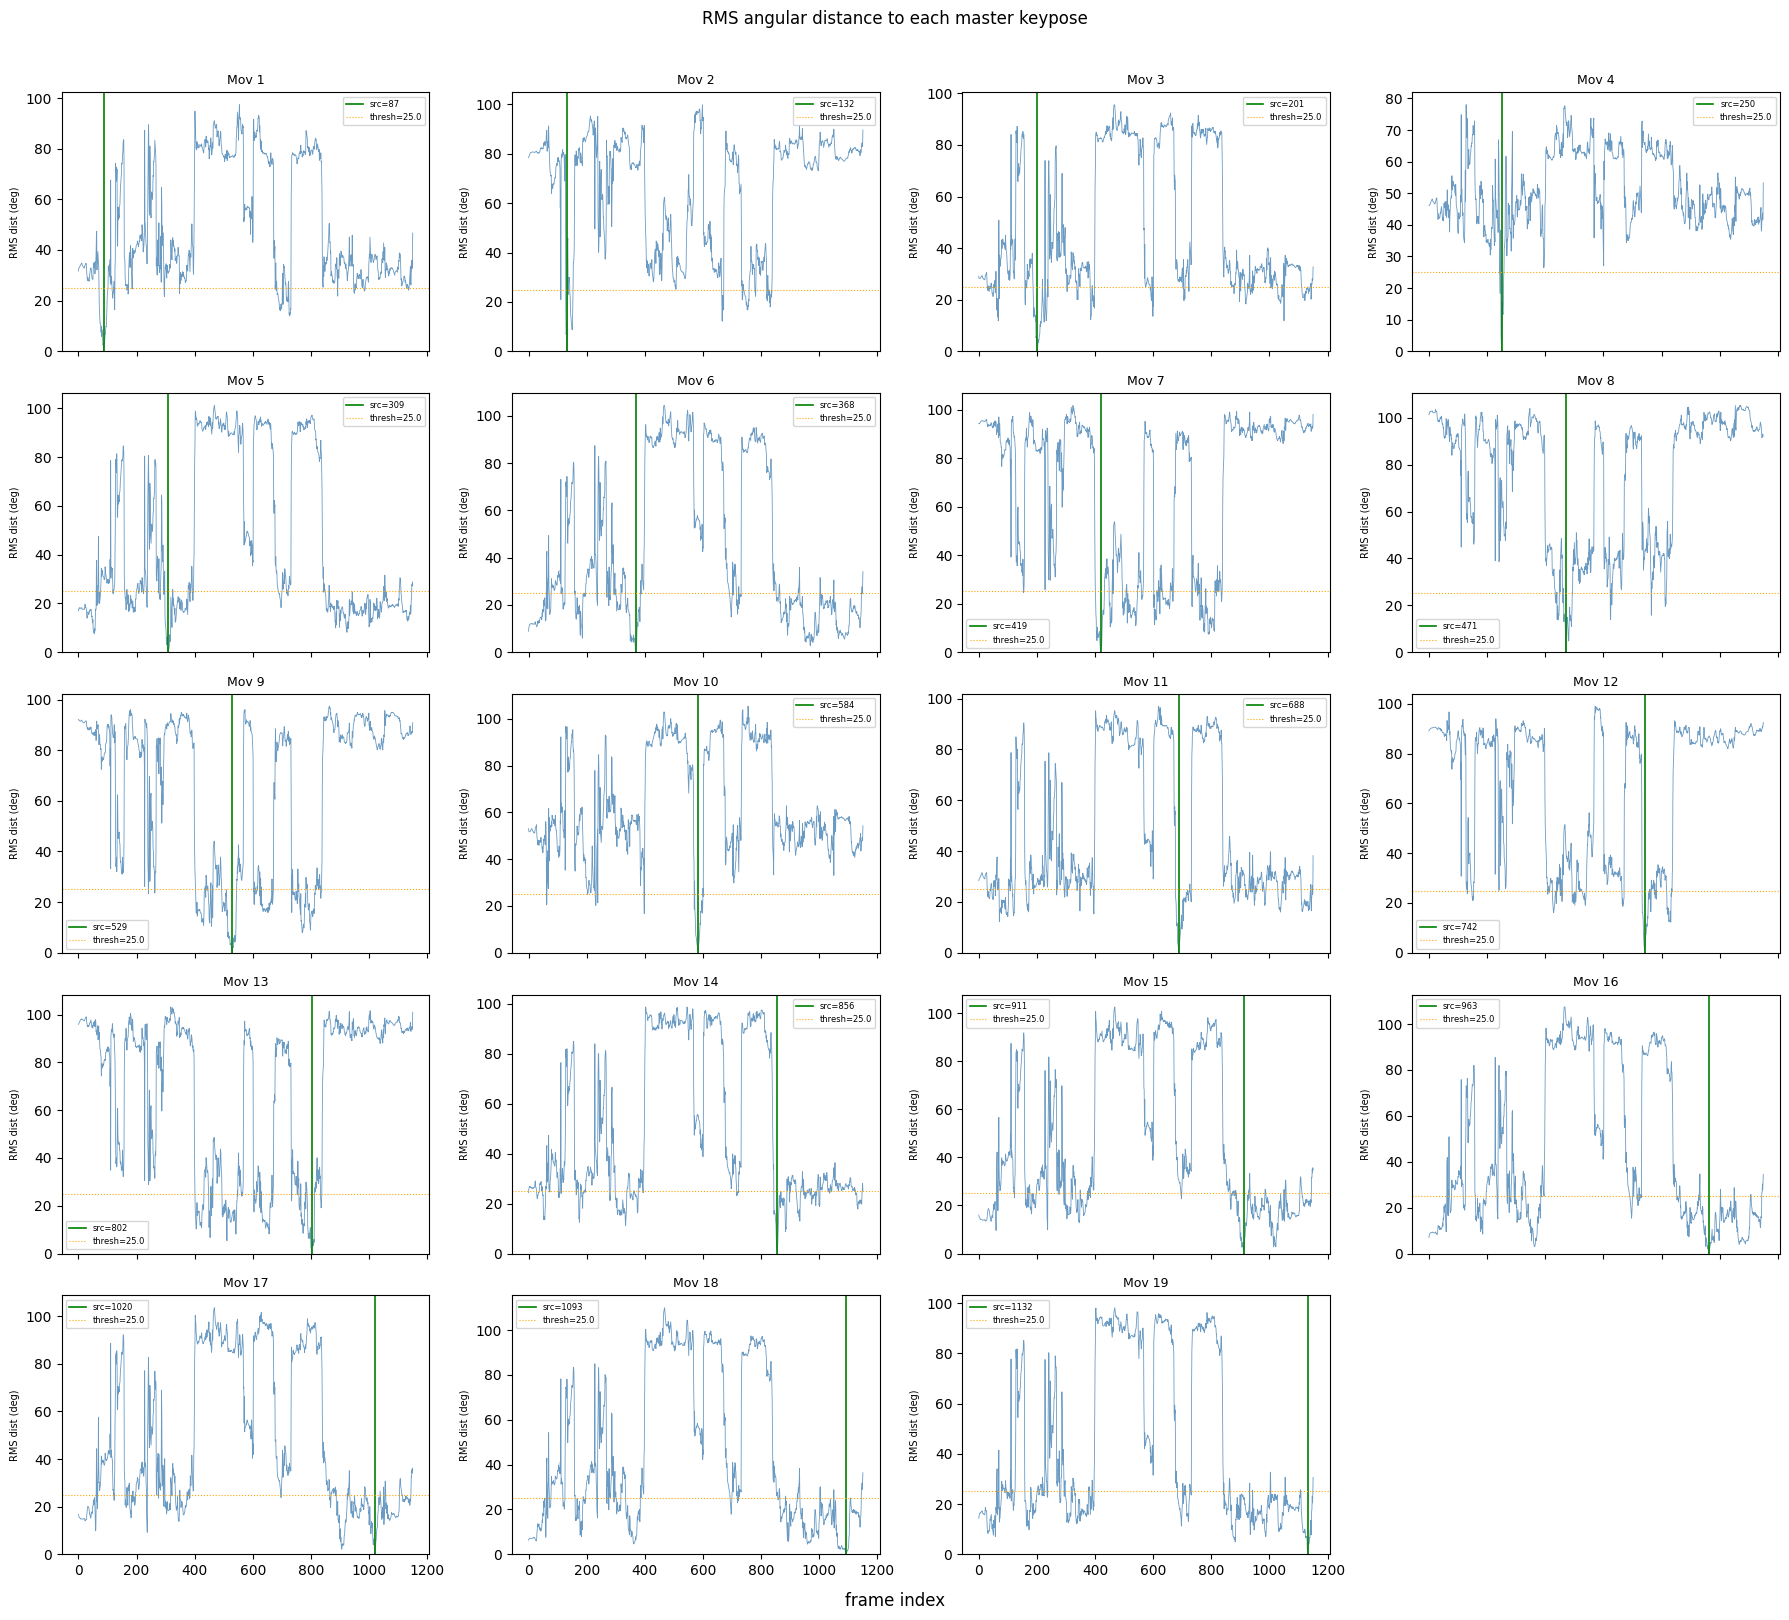

In [9]:
ncols = 4
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 16), sharex=True)
axes = axes.flatten()

cand_by_idx = {c["movement_index"]: c for c in candidates}

for i, kp in enumerate(bootstrap_keyposes):
    ax = axes[i]
    midx = kp["movement_index"]
    dists = np.array(distance_arrays[midx])
    src = kp["source_frame"]
    best = cand_by_idx[midx]["best_frame"]

    ax.plot(frame_indices, dists, linewidth=0.6, color="steelblue", alpha=0.8)
    ax.axvline(src, color="green", linewidth=1.2, label=f"src={src}")
    if best != src:
        ax.axvline(best, color="red", linewidth=1.2, linestyle="--", label=f"best={best}")
    ax.axhline(THRESHOLD, color="orange", linewidth=0.8, linestyle=":", label=f"thresh={THRESHOLD}")
    ax.set_title(f"Mov {midx}", fontsize=9)
    ax.set_ylabel("RMS dist (deg)", fontsize=7)
    ax.legend(fontsize=6)
    ax.set_ylim(0, None)

# hide unused subplots
for j in range(len(bootstrap_keyposes), len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("frame index")
plt.suptitle("RMS angular distance to each master keypose", y=1.01)
plt.tight_layout()
plt.show()

## Step 5: Separation analysis

For each keypose, compare:
- `min_dist`: distance at the correct source frame (should be ≈ 0)
- `second_min_dist`: distance at the next-closest frame (should be >> min_dist)

High separation → the matcher can reliably distinguish this movement from similar-looking frames.

In [10]:
print(f"{'Mov':>4} {'src':>6} {'min_dist':>10} {'2nd_min':>10} {'separation':>12}")
print("-" * 50)

for kp in bootstrap_keyposes:
    midx = kp["movement_index"]
    src = kp["source_frame"]
    dists = np.array(distance_arrays[midx])

    # Exclude a ±3 frame window around source to find second minimum
    src_pos = frame_indices.index(src) if src in frame_indices else None
    min_dist = dists[src_pos] if src_pos is not None else float("inf")

    mask = np.ones(len(dists), dtype=bool)
    if src_pos is not None:
        lo = max(0, src_pos - 3)
        hi = min(len(dists), src_pos + 4)
        mask[lo:hi] = False
    second_min = dists[mask].min() if mask.any() else float("inf")
    separation = second_min - min_dist

    print(
        f"{midx:>4} {src:>6} {min_dist:>10.4f} {second_min:>10.4f} {separation:>12.4f}"
    )

 Mov    src   min_dist    2nd_min   separation
--------------------------------------------------
   1     87     0.0000     4.9201       4.9201
   2    132     0.0000     8.7126       8.7126
   3    201     0.0000     3.4546       3.4546
   4    250     0.0000    11.6662      11.6662
   5    309     0.0000     2.8265       2.8265
   6    368     0.0000     2.7392       2.7392
   7    419     0.0000     2.7154       2.7154
   8    471     0.0000     4.7137       4.7137
   9    529     0.0000     2.0873       2.0873
  10    584     0.0000     2.9964       2.9964
  11    688     0.0000     4.4004       4.4004
  12    742     0.0000     7.5671       7.5671
  13    802     0.0000     3.2692       3.2692
  14    856     0.0000     6.4376       6.4376
  15    911     0.0000     2.6246       2.6246
  16    963     0.0000     2.0245       2.0245
  17   1020     0.0000     2.1209       2.1209
  18   1093     0.0000     1.6010       1.6010
  19   1132     0.0000     4.3349       4.3349


## Validation Checklist

- [ ] All 19 matched (dist <= threshold)
- [ ] All 19 best_frame == source_frame (delta = 0)
- [ ] All min_dist ≈ 0.0 (bootstrap exact match)
- [ ] Separation > 10 deg for all movements (clear global minimum)
- [ ] No movement shows a second minimum below threshold at a different frame

**Next step**: If all pass, an instructor can mark real completion frames
(different from velocity boundaries) and re-run this notebook to confirm
the matcher finds the correct frames with low distance.

In [11]:
# Automated pass/fail summary
all_matched = all(c["matched"] for c in candidates)
all_exact = all(
    c["best_frame"] == c["source_frame"] for c in candidates
    if c["source_frame"] is not None
)

print("=" * 40)
print(f"All 19 matched  : {'PASS' if all_matched else 'FAIL'}")
print(f"All exact match : {'PASS' if all_exact  else 'FAIL'}")
print("=" * 40)

if all_matched and all_exact:
    print("\nAngle-matching algorithm is correct on bootstrap data.")
    print("Ready to test with instructor-marked keyposes.")
else:
    failed = [c for c in candidates if not c["matched"] or c["best_frame"] != c["source_frame"]]
    print(f"\nFailed movements: {[c['movement_index'] for c in failed]}")
    print("Check distance curves above for clues.")

All 19 matched  : PASS
All exact match : PASS

Angle-matching algorithm is correct on bootstrap data.
Ready to test with instructor-marked keyposes.


---
## Review 1: 임계값 분석

Bootstrap에서는 `source_dist = 0.0`이므로 어떤 임계값이든 통과한다.
진짜 문제는 **실제 여유 공간** — `2nd_min`이 작을수록 사범이 완성 프레임을
조금만 잘못 찍어도 오탐이 발생한다.

- `2nd_min`: source ±3 범위 외에서 가장 가까운 프레임의 거리
- `rec_thresh`: `2nd_min / 2` — 실사용 가능한 최대 임계값 추정치
- **HIGH risk**: `2nd_min < 3 deg` → 동작별 임계값 필수

In [ ]:
threshold_data = []
for kp in bootstrap_keyposes:
    midx = kp["movement_index"]
    src = kp["source_frame"]
    dists = np.array(distance_arrays[midx])
    src_pos = frame_indices.index(src)
    source_dist = dists[src_pos]

    mask = np.ones(len(dists), dtype=bool)
    mask[max(0, src_pos - 3):min(len(dists), src_pos + 4)] = False
    second_min = dists[mask].min()
    second_frame = frame_indices[np.where(mask)[0][np.argmin(dists[mask])]]
    recommended = second_min / 2.0
    risk = "HIGH" if second_min < 3.0 else ("MED" if second_min < 6.0 else "LOW")

    threshold_data.append(dict(
        movement=midx, src=src, source_dist=source_dist,
        second_min=second_min, second_frame=second_frame,
        recommended=recommended, risk=risk,
    ))

print(f"{'Mov':>4} {'src':>6} {'2nd_min':>9} {'2nd_frame':>10} {'rec_thresh':>11} {'risk':>6}")
print("-" * 55)
for d in threshold_data:
    print(f"{d['movement']:>4} {d['src']:>6} {d['second_min']:>9.4f} "
          f"{d['second_frame']:>10} {d['recommended']:>11.4f} {d['risk']:>6}")

mins = [d["second_min"] for d in threshold_data]
high_risk = [d["movement"] for d in threshold_data if d["risk"] == "HIGH"]
print(f"\n2nd_min 범위: {min(mins):.2f} ~ {max(mins):.2f} deg")
print(f"threshold=25.0은 너무 관대 — 실제 매칭 거리가 2nd_min보다 작아야 함")
print(f"HIGH risk 동작 (2nd_min < 3 deg): {high_risk}")
print(f"동작별 임계값 필요: {'YES' if min(mins) < 3.0 else 'NO'}")

In [ ]:
# 막대 그래프: 동작별 2nd_min 시각화
fig, ax = plt.subplots(figsize=(14, 4))
movements = [d["movement"] for d in threshold_data]
second_mins = [d["second_min"] for d in threshold_data]
colors = ["red" if d["risk"] == "HIGH" else ("orange" if d["risk"] == "MED" else "steelblue")
          for d in threshold_data]

ax.bar(movements, second_mins, color=colors, edgecolor="white")
ax.axhline(3.0, color="red", linestyle="--", linewidth=1.0, label="HIGH risk 경계 (3 deg)")
ax.axhline(6.0, color="orange", linestyle="--", linewidth=1.0, label="MED risk 경계 (6 deg)")
ax.set_xlabel("Movement index")
ax.set_ylabel("2nd_min distance (deg)")
ax.set_title("동작별 분리도 (빨강=HIGH risk, 주황=MED, 파랑=LOW)")
ax.set_xticks(movements)
ax.legend()
plt.tight_layout()
plt.show()

print("결론: HIGH risk 동작들은 각도 신호만으로 구분이 어려움.")
print("      → 이 동작들은 velocity 신호에 더 의존하거나 동작별 임계값 적용 필요.")

---
## Review 2: 관절별 거리 기여도 분석

각 동작에 대해 **가장 혼동되는 프레임** (source ±3 제외 최소 거리 프레임)에서
어떤 관절 각도가 분리를 만들어내는지 분해한다.

- 기여도 높음 → 이 관절이 해당 동작을 구분하는 핵심 신호
- 기여도 낮음 → 이 관절은 인접 프레임과 각도가 비슷 (식별력 없음)

`r_hip`, `l_hip`, `sh_line`, `hip_line`이 전반적으로 낮다면 제거를 고려.

In [ ]:
contribution_matrix = []   # (19, 8) — 기여도 %
raw_diff_matrix = []       # (19, 8) — 절대 각도 차이 (deg)

for kp in bootstrap_keyposes:
    midx = kp["movement_index"]
    src = kp["source_frame"]
    kp_angles = kp["angles"]
    dists = np.array(distance_arrays[midx])
    src_pos = frame_indices.index(src)

    mask = np.ones(len(dists), dtype=bool)
    mask[max(0, src_pos - 3):min(len(dists), src_pos + 4)] = False
    second_pos = np.where(mask)[0][np.argmin(dists[mask])]
    second_angles = all_frame_angles[second_pos][1]

    sq_diffs, abs_diffs = [], []
    for key in ANGLE_KEYS:
        if key in second_angles and key in kp_angles:
            diff = second_angles[key] - kp_angles[key]
            if "line_angle" in key:
                diff = (diff + 180.0) % 360.0 - 180.0
            sq_diffs.append(diff ** 2)
            abs_diffs.append(abs(diff))
        else:
            sq_diffs.append(0.0)
            abs_diffs.append(0.0)

    total = sum(sq_diffs) or 1.0
    contribution_matrix.append([s / total * 100 for s in sq_diffs])
    raw_diff_matrix.append(abs_diffs)

# 기여도 테이블 출력
short_keys = ["r_knee", "l_knee", "r_elbow", "l_elbow", "r_hip", "l_hip", "sh_line", "hip_line"]
print("가장 혼동되는 프레임에서의 관절별 기여도 (%)")
print(f"{'Mov':>4}", end="")
for k in short_keys:
    print(f" {k:>8}", end="")
print()
print("-" * (4 + 9 * len(ANGLE_KEYS)))
for i, kp in enumerate(bootstrap_keyposes):
    print(f"{kp['movement_index']:>4}", end="")
    for pct in contribution_matrix[i]:
        print(f" {pct:>8.1f}", end="")
    print()

mat = np.array(contribution_matrix)
print(f"\n{'avg':>4}", end="")
for avg in mat.mean(axis=0):
    print(f" {avg:>8.1f}", end="")
print()

top_joint = short_keys[int(mat.mean(axis=0).argmax())]
low_joints = [short_keys[j] for j in range(len(short_keys)) if mat.mean(axis=0)[j] < 5.0]
print(f"\n가장 식별력 높은 관절: {top_joint}")
print(f"평균 기여도 < 5% 관절 (제거 고려): {low_joints}")

In [ ]:
# 히트맵: 기여도(%) + 절대 각도 차이(deg)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mov_labels = [f"Mov {kp['movement_index']}" for kp in bootstrap_keyposes]

# 왼쪽: 기여도 %
im0 = axes[0].imshow(contribution_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
axes[0].set_xticks(range(len(short_keys)))
axes[0].set_xticklabels(short_keys, rotation=40, ha="right", fontsize=8)
axes[0].set_yticks(range(len(bootstrap_keyposes)))
axes[0].set_yticklabels(mov_labels, fontsize=8)
axes[0].set_title("관절별 기여도 % (혼동 프레임 기준)")
plt.colorbar(im0, ax=axes[0], label="% of squared distance")
for i in range(len(bootstrap_keyposes)):
    for j in range(len(short_keys)):
        val = contribution_matrix[i][j]
        axes[0].text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6,
                     color="white" if val > 60 else "black")

# 오른쪽: 절대 각도 차이 (deg)
im1 = axes[1].imshow(raw_diff_matrix, aspect="auto", cmap="Blues", vmin=0)
axes[1].set_xticks(range(len(short_keys)))
axes[1].set_xticklabels(short_keys, rotation=40, ha="right", fontsize=8)
axes[1].set_yticks(range(len(bootstrap_keyposes)))
axes[1].set_yticklabels(mov_labels, fontsize=8)
axes[1].set_title("절대 각도 차이 deg (혼동 프레임 기준)")
plt.colorbar(im1, ax=axes[1], label="degrees")
for i in range(len(bootstrap_keyposes)):
    for j in range(len(short_keys)):
        axes[1].text(j, i, f"{raw_diff_matrix[i][j]:.1f}",
                     ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

---
## Review 3: 동작별 거리 시계열 — 줌 뷰

source 프레임 ±50 범위로 확대. 분리도가 낮은 동작은 넓고 얕은 minimum을 보임.  
테두리 색상 = risk 수준 (빨강=HIGH, 주황=MED, 파랑=LOW).

In [ ]:
risk_color = {"HIGH": "red", "MED": "orange", "LOW": "steelblue"}
risk_map = {d["movement"]: d["risk"] for d in threshold_data}
second_map = {d["movement"]: d["second_frame"] for d in threshold_data}
rec_thresh_map = {d["movement"]: d["recommended"] for d in threshold_data}

ncols, nrows = 4, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 16))
axes = axes.flatten()
frame_arr = np.array(frame_indices)

for i, kp in enumerate(bootstrap_keyposes):
    ax = axes[i]
    midx = kp["movement_index"]
    src = kp["source_frame"]
    dists = np.array(distance_arrays[midx])
    risk = risk_map[midx]
    second_f = second_map[midx]
    rec = rec_thresh_map[midx]
    col = risk_color[risk]

    zoom_lo = max(0, src - 50)
    zoom_hi = min(frame_arr[-1], src + 50)
    zoom_mask = (frame_arr >= zoom_lo) & (frame_arr <= zoom_hi)
    fi_zoom = frame_arr[zoom_mask]
    d_zoom = dists[zoom_mask]

    ax.plot(fi_zoom, d_zoom, linewidth=0.9, color="steelblue", alpha=0.85)
    ax.axvline(src, color="green", linewidth=1.5, label=f"src={src}")
    if zoom_lo <= second_f <= zoom_hi:
        ax.axvline(second_f, color="red", linewidth=1.0, linestyle="--",
                   alpha=0.7, label=f"2nd={second_f}")
    ax.axhline(rec, color=col, linewidth=0.9, linestyle=":", label=f"rec={rec:.1f}deg")

    ax.set_title(f"Mov {midx}  [{risk}]  sep={threshold_data[i]['second_min']:.2f}deg",
                 fontsize=8, color=col, fontweight="bold")
    ax.set_ylabel("dist (deg)", fontsize=7)
    ax.set_xlim(zoom_lo, zoom_hi)
    ax.set_ylim(0, None)
    ax.legend(fontsize=6)
    for spine in ax.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(2.0 if risk == "HIGH" else 0.8)

for j in range(len(bootstrap_keyposes), len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("frame index")
plt.suptitle("거리 시계열 — ±50프레임 줌  (테두리 색 = risk)", y=1.01)
plt.tight_layout()
plt.show()

---
## 종합 결론

### 1. 임계값
- `threshold=25.0`은 실용적으로 의미 없음. 실제 허용치는 `min(2nd_min)` ≈ **1.6 deg** (Mov 18)
- 동작별 권장 임계값 = `rec_thresh_map` 값 사용
- HIGH risk 동작(9, 16, 17, 18): 각도 신호 단독으로는 구분 불가 → velocity 신호에 의존 필요

### 2. 관절 기여도
- 히트맵에서 전반적으로 낮은 관절 → `ANGLE_KEYS`에서 제거하거나 가중치 낮추기
- 특히 `sh_line`, `hip_line`이 많은 동작에서 거의 0이면 제거 유력

### 3. 다음 단계
- [ ] 기여도 < 5% 관절 제거 후 분리도 재측정
- [ ] 사범이 실제 완성 프레임 마킹 → `source_dist` 측정 (bootstrap 0이 아닌 실제값)
- [ ] `03b_velocity_valleys.ipynb` 구현 (velocity 신호 단독 검증)